In [1]:
from keras.models import Sequential
from keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten, Dropout
from keras.utils import plot_model, to_categorical
from keras.datasets import cifar10
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 82s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
x_test.shape

(10000, 32, 32, 3)

In [5]:
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [6]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

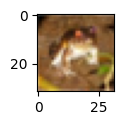

In [8]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])

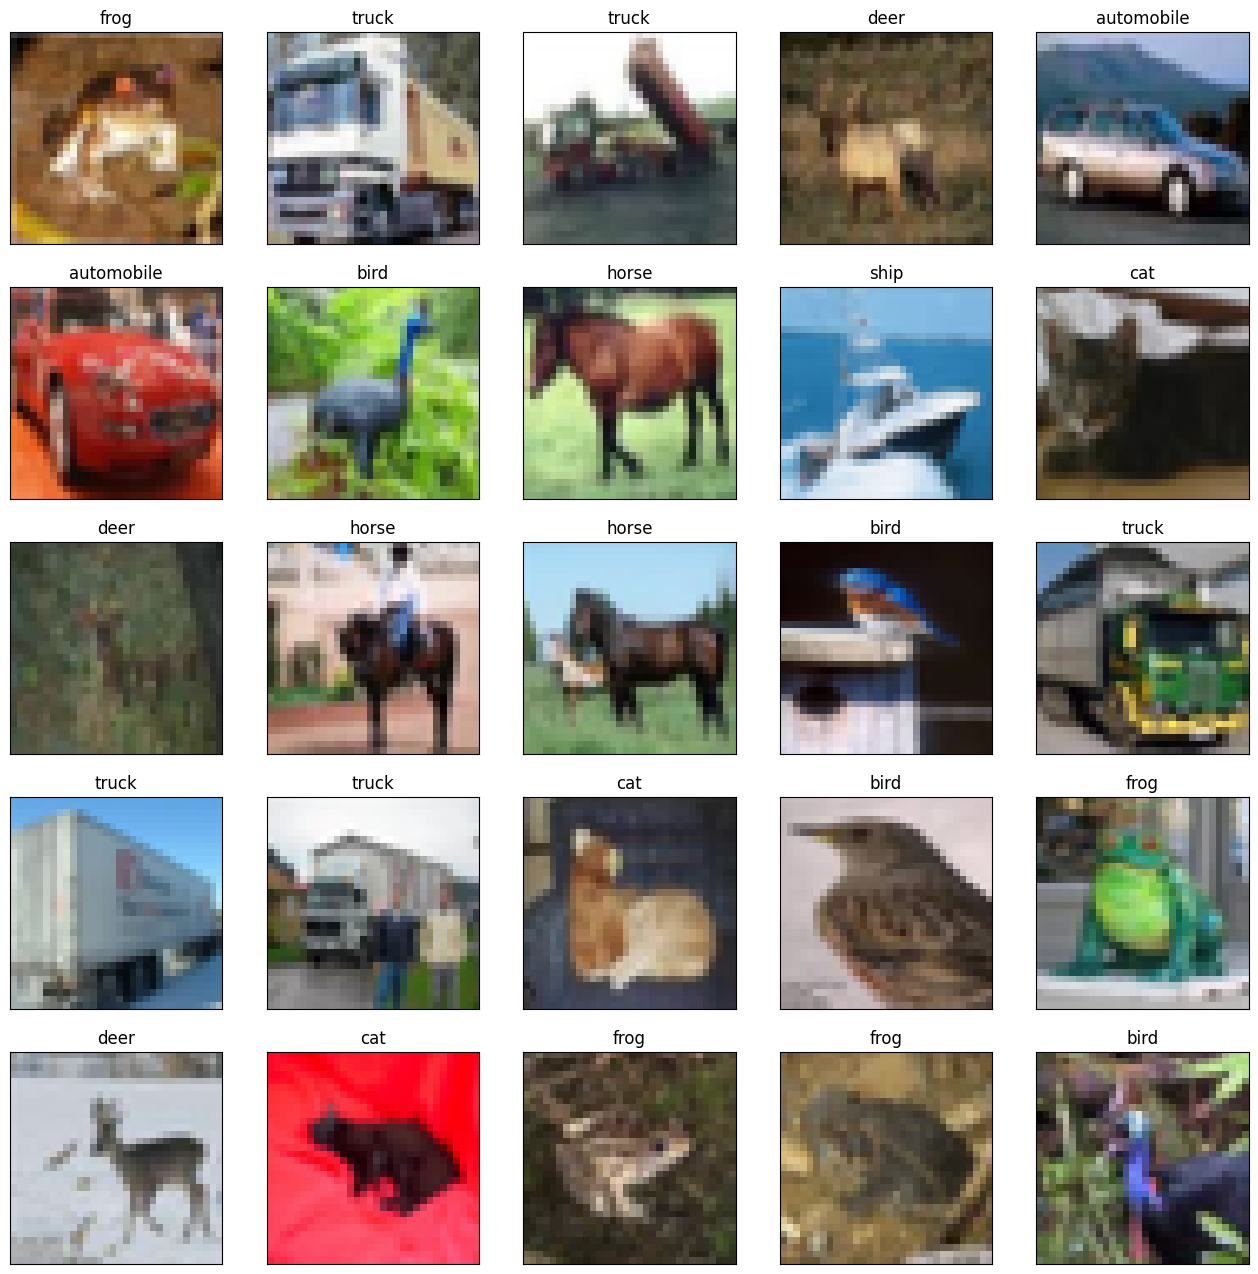

In [15]:
plt.figure(figsize=(16,16))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])    
    plt.title(labels[y_train[i][0]])
    plt.xticks([]);
    plt.yticks([])

In [16]:
model=Sequential()
model.add(Input(shape=(32,32,3)))
model.add(Conv2D(filters=32, kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=16, kernel_size=(3,3),activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         147,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 187,418 (732.10 KB)

 Trainable params: 187,418 (732.10 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [20]:
model.fit(x_train,y_train,epochs=10,batch_size=10)

Epoch 1/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.2061 - loss: 2.2116
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 35s 7ms/step - accuracy: 0.4315 - loss: 1.5646
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.4940 - loss: 1.4169
Epoch 4/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.5319 - loss: 1.3250
Epoch 5/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.5541 - loss: 1.2685
Epoch 6/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.5769 - loss: 1.2136
Epoch 7/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.5948 - loss: 1.1705
Epoch 8/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.6109 - loss: 1.1291
Epoch 9/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.6247 - loss: 1.0924
Epoch 10/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - accuracy: 0.6331 - loss: 1.0692


In [21]:
model.evaluate(x_test,y_test,batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - accuracy: 0.5914 - loss: 1.2362


[1.2362138032913208, 0.5914000272750854]

## Predict a new data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


'frog'

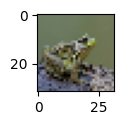

In [38]:
new = cv2.imread("D:\\AshleshaRuchika\\PGCP-AI\\NLP\\images\\frog.jpg")
new  = cv2.cvtColor(new,cv2.COLOR_BGR2RGB)
new= cv2.resize(new, (32,32))
plt.figure(figsize=(1,1))
plt.imshow(new)
new = new.reshape(1,32,32,3)
result = model.predict(new)
result = result.argmax()
labels[result]


In [39]:
# new_batch = np.expand_dims(new, axis=0)
# print(new_batch)
# pred = model.predict(new_batch, verbose=False)
# predicted_class = np.argmax(pred)

# print("Predicted Class ID:", predicted_class)
# print("Predicted Label:", labels[predicted_class])

[[[[[110 124  99]
    [110 124  99]
    [112 125 100]
    ...
    [112 121  90]
    [112 121  90]
    [112 121  90]]

   [[109 123  98]
    [109 123  98]
    [110 124  99]
    ...
    [112 121  90]
    [112 121  90]
    [112 121  90]]

   [[109 123  98]
    [109 123  98]
    [110 124  99]
    ...
    [112 121  90]
    [112 121  90]
    [112 121  90]]

   ...

   [[110 120 155]
    [116 120 160]
    [ 78  86 122]
    ...
    [145 141 146]
    [105  95  95]
    [182 173 175]]

   [[ 70  77  99]
    [ 77  86 125]
    [ 90 101 133]
    ...
    [162 160 164]
    [150 140 132]
    [128 120 117]]

   [[ 95  99 106]
    [109 114 138]
    [ 98 105 131]
    ...
    [165 160 151]
    [133 128 125]
    [165 154 148]]]]]


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=uint8)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>